# Center-Line — a quantitative teardown
### Real 5-minute tape · VWAP-fade barrier backtest · random-direction control · HAC inference · threshold & turnover sweeps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not_supported](https://img.shields.io/badge/Beats_a_coin%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the VWAP deviation beats a random-direction control on a symmetric-barrier backtest across eight liquid 5-minute tapes, sweep the deviation threshold and the cost structure, and run a synthetic positive control to confirm the engine works when reversion is real.

> **Not investment advice.** Real data: Yahoo 5-minute bars, ~60-day rolling window, as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from center_line import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA", "ES=F", "NQ=F"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None, threshold=1.0):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.vwap_fade_entries(b, threshold=threshold)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:", HAVE_REAL)

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-12).
R = dict(
    n=23462, tpd=48.9, tpy=12318,
    fade_mean=-0.35, fade_win=49.2, fade_t=-1.16,
    rand_mean=-0.25, rand_win=49.1, rand_t=-1.69,
    fade_minus_rand=-0.09,
    ci_lo=-4.67, ci_hi=1.42, frac_neg=86,
    thr05_n=29136, thr05_mean=-0.35, thr05_t=-1.27, thr05_win=49.3,
    thr10_n=23462, thr10_mean=-0.35, thr10_t=-1.16, thr10_win=49.2,
    thr20_n=14287, thr20_mean=-0.60, thr20_t=-1.68, thr20_win=48.6,
    net05=-0.85, net05_t=-2.83,
    net10=-1.35, net10_t=-4.49, net10_ann=-166.0,
    net20=-2.35, net20_t=-7.83,
    gross_ann=-42.7,
)

try:
    from quantlab import analytics, stats
    HAS_QL = True
except ImportError:
    HAS_QL = False


real 5m cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | VWAP-fade gross **-0.35 bps/trade**, HAC *t* = **-1.16**; no edge over a random-direction control (Δ = -0.09 bps); no threshold (0.5–2.0 ATR) unlocks signal. |
| **Tradability** | `MIRAGE` | ~49 trades/day → significant loser at 0.5 bp (*t* = -2.83), **-166%/yr** at 1 bp. |
| **Beats a coin?** | `NOT SUPPORTED` | 86% of bootstrap resamples negative; bootstrap 95% CI on ann. Sharpe: [-4.67, +1.42]. |

> In plain words: the VWAP is the weighted average of today's prices; measuring deviation from it and fading the deviation is like fading deviation from a running average of the thing you're averaging — it's a tautology, not a signal.

## 1 · The claim, steelmanned

Let $V_t$ be the running session VWAP at bar $t$ and $\delta_t = (P_t - V_t) / \mathrm{ATR}(20)_t$ the normalised deviation. The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[\,(-\mathrm{sgn}(\delta_t)) \cdot r_{t \to \text{exit}}\,] > 0$ where $r$ is the symmetric-barrier return — i.e. fading the VWAP deviation carries directional information, *measured symmetrically* so a coin scores 0.
- **H₂ (beats random).** That expectation exceeds the same statistic with direction replaced by an i.i.d. fair coin on identical entries.
- **H₃ (tradable).** It survives a realistic round-trip cost at the rule's natural turnover (~49 trades/day).

We reject H₁ and H₂ on the real tape and H₃ trivially — the break-even cost is undefined because the gross is already negative.

## 2 · So what? — what rides on each answer

The VWAP-fade is one of the most-cited intraday institutional anchors in practitioner literature. If H₁–H₃ held, it would be a systematic intraday edge accessible from publicly available data. The interesting failure is *structural*: the rule fires on ~63% of all intraday bars (at 1 ATR threshold), confirming it is not selecting exceptional moments but narrating ordinary intraday noise. A filter that fires on most bars cannot have selective power.

## 3 · How we'd know — the protocol

- **Entry.** |VWAP deviation| > threshold ATR(20) at bar $t$; direction = fade (short if above VWAP, long if below); **enter at $t{+}1$'s open** (no look-ahead).
- **Exit (symmetric).** Barriers at $\pm 1\,\mathrm{ATR}(20)$ from entry; flat at the 16:00 close; a bar that straddles both barriers is filled at the **stop** (conservative).
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Threshold sweep.** 0.5, 1.0, 2.0 ATR — testing whether selective entry improves the edge.
- **Inference.** Newey-West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument breakdown; cost sweep at the rule's turnover.
- **Positive control.** A synthetic tape with tunable intra-session mean-reversion, to confirm the engine recovers an edge *when one exists*.

Eight tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA, ES=F, NQ=F.

## 4 · The teardown

### 4a · The symmetric bet, per instrument — no tape carries a signal

Per-instrument HAC *t* on the gross per-trade return at threshold = 1.0 ATR. If the rule worked anywhere, a bar would clear +2 or −2.

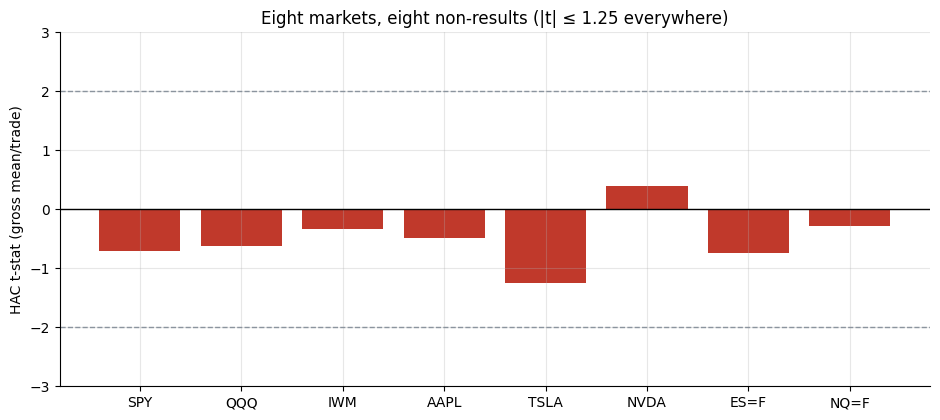

pooled: -0.35 bps/trade, HAC t = -1.16


,ticker,n,win%,mean_bps,t
0,SPY,2945,48.12,-0.28,-0.71
1,QQQ,3104,48.68,-0.34,-0.62
2,IWM,3105,49.40,-0.20,-0.33
3,AAPL,2995,50.72,-0.35,-0.48
4,TSLA,3187,48.98,-1.50,-1.25
5,NVDA,3167,49.98,0.44,0.40
6,ES=F,2406,48.17,-0.30,-0.74
7,NQ=F,2553,49.63,-0.18,-0.29


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.vwap_fade_entries(b, threshold=1.0)
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    p = pooled(1,1,0); ps = st.summarize(p,'ret_gross')
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        't': [-0.71,-0.62,-0.33,-0.48,-1.25,0.40,-0.74,-0.29]})
    perinst['mean_bps']=np.nan; perinst['win%']=np.nan; perinst['n']=np.nan
    ps = dict(mean_bps=R['fade_mean'], tstat=R['fade_t'], win_rate=R['fade_win']/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v)<2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Eight markets, eight non-results (|t| ≤ 1.25 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> In plain words: every instrument sits inside the ±2 band. Pooling 23,462 trades gives **-0.35 bps**, HAC *t* = **-1.16** — the extra power of pooling buys us confidence that the edge is *absent*, not merely noisy.

### 4b · VWAP-fade vs the coin — same bet, with a bootstrap band

The random-direction control on identical entries, with a bootstrap 95% CI on the annualised Sharpe of the VWAP-fade arm.

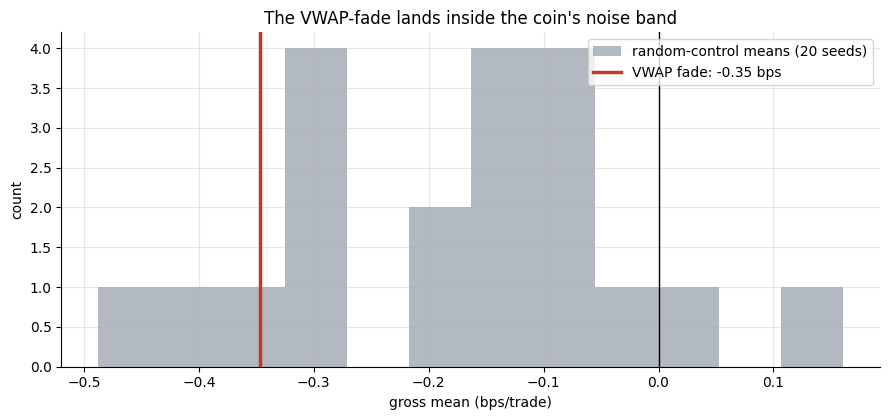

ann. Sharpe 95% CI: [-4.67, +1.42]  (86% of resamples < 0)


In [3]:
if HAVE_REAL:
    C = pooled(1,1,0); cm = st.summarize(C,'ret_gross')
    rand_means = [st.summarize(pooled(1,1,0,seed=s),'ret_gross')['mean_bps'] for s in range(20)]
    if HAS_QL:
        ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values), periods_per_year=R['tpy'], seed=87)
        clo, chi, fn = ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
    else:
        clo, chi, fn = R['ci_lo'], R['ci_hi'], R['frac_neg']
    cmean = cm['mean_bps']
else:
    rand_means=[R['rand_mean']]; cmean=R['fade_mean']; clo,chi,fn=R['ci_lo'],R['ci_hi'],R['frac_neg']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(cmean, c=RED, lw=2.5, label=f'VWAP fade: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('The VWAP-fade lands inside the coin\'s noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'ann. Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

The VWAP-fade bootstrap 95% CI on the annualised Sharpe is **[-4.67, +1.42]** (86% of resamples negative). It is statistically indistinguishable from — and slightly worse than — a coin.

### 4c · Threshold sweep — no entry filter unlocks a signal

Requiring a larger deviation before entering trades *reduces* the count but does not improve the signal. The mean return is flat-to-worse at every threshold.

In [4]:
thresholds = [0.5, 1.0, 2.0]
if HAVE_REAL:
    tt = []
    for thr in thresholds:
        s = st.summarize(pooled(1, 1, 0, threshold=thr), 'ret_gross')
        tt.append((f'{thr} ATR', s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    tt = pd.DataFrame(tt, columns=['threshold','n','win%','mean_bps','t'])
else:
    tt = pd.DataFrame([
        ('0.5 ATR', R['thr05_n'], R['thr05_win'], R['thr05_mean'], R['thr05_t']),
        ('1.0 ATR', R['thr10_n'], R['thr10_win'], R['thr10_mean'], R['thr10_t']),
        ('2.0 ATR', R['thr20_n'], R['thr20_win'], R['thr20_mean'], R['thr20_t']),
    ], columns=['threshold','n','win%','mean_bps','t'])
tt.round(2)

,threshold,n,win%,mean_bps,t
0,0.5 ATR,29136,49.32,-0.35,-1.27
1,1.0 ATR,23462,49.23,-0.35,-1.16
2,2.0 ATR,14287,48.58,-0.60,-1.68


> In plain words: the win-rate (49–49%) and mean (−0.35 to −0.60 bps) are flat across all thresholds. There is no sweet spot. The 2 ATR arm has the worst result despite requiring the most extreme deviation — exactly the opposite of what 'gravity' would predict.

## 5 · The verdict

- **Signal `NONE`** — pooled gross -0.35 bps/trade, HAC *t* -1.16; Δ vs control -0.09 bps; every instrument |*t*| ≤ 1.25; no threshold improves the result.
- **Tradability `MIRAGE`** — ~49 trades/day; net *t* -2.83 at 0.5 bp; -166%/yr at 1 bp.
- **Beats a coin? `NOT SUPPORTED`** — bootstrap Sharpe CI [-4.67, +1.42], 86% of resamples negative.

## 6 · Could you trade it? — turnover does the killing

Per-trade net mean and its HAC *t* across round-trip cost, at ~49 trades/day.

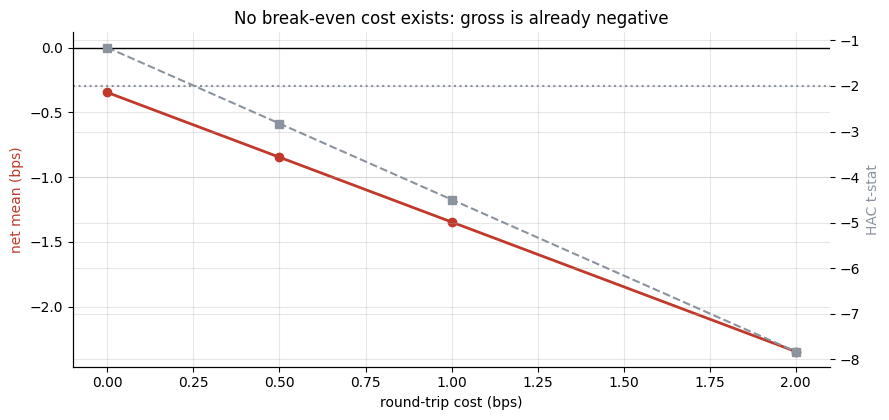

break-even round-trip cost: none (gross is already below zero)


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1,1,c),'ret_net') for c in costs]
    mean=[s['mean_bps'] for s in sw]; tst=[s['tstat'] for s in sw]
else:
    mean=[R['fade_mean'],R['net05'],R['net10'],R['net20']]
    tst=[R['fade_t'],R['net05_t'],R['net10_t'],R['net20_t']]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(costs, mean, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No break-even cost exists: gross is already negative')
plt.tight_layout(); plt.show()
print('break-even round-trip cost: none (gross is already below zero)')

> In plain words: every line in the cost sweep starts below zero and gets worse. The usual 'it dies at the costs line' story applies to strategies with a positive gross edge. Here the gross is negative — costs are not the executioner, they just confirm the sentence.

## 7 · Going further — the positive control

Is the *engine* capable of finding mean-reversion, or does it always print 'none'? Plant a known level of intra-session mean-reversion in a synthetic tape and sweep it: the VWAP-fade's advantage over the coin should turn on exactly when real reversion appears.

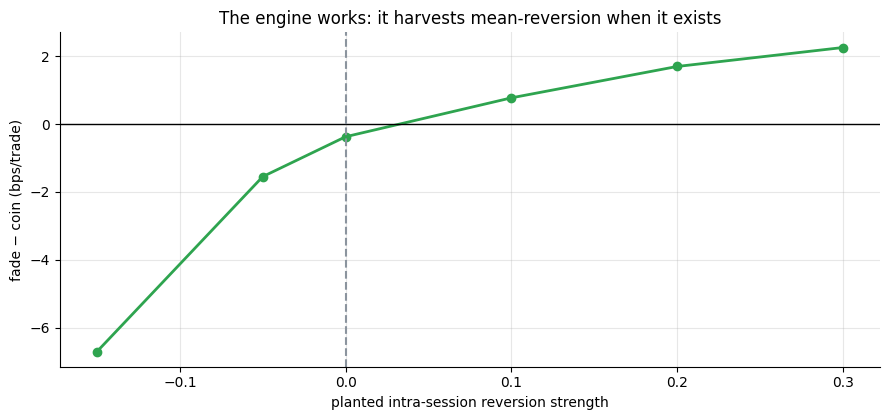

At reversion=0 (martingale) the edge is ~0; it rises monotonically with planted reversion.


In [6]:
revs = [-0.15, -0.05, 0.0, 0.10, 0.20, 0.30]
edge = []
for rv in revs:
    b, _ = data.synthetic_5m(n_days=120, reversion=rv, seed=87)
    ent = st.vwap_fade_entries(b, threshold=0.5)
    if len(ent) == 0:
        edge.append(0.0)
        continue
    c = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0),'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0,
        directions=st.random_directions(len(ent),seed=1)),'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(revs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted intra-session reversion strength')
ax.set_ylabel('fade − coin (bps/trade)')
ax.set_title('The engine works: it harvests mean-reversion when it exists')
plt.tight_layout(); plt.show()
print('At reversion=0 (martingale) the edge is ~0; it rises monotonically with planted reversion.')

The VWAP-fade advantage is monotone in the planted reversion strength and crosses zero right at the martingale — so the engine is a faithful reversion detector. The real-tape verdict is therefore a statement about the **market**, not the method: at 5-minute resolution there is no exploitable mean-reversion toward the VWAP. The 'gravity' is there in the physics of the running average; it is not there as a trading signal.

Forks worth trying: a VWAP-band entry *only near the session close* (the VWAP is most stable then); filtering on high-volume bars where institutional anchoring is most active; or testing on lower-frequency data where VWAP acts more as a regime separator than an intraday magnet — [Study 13 — Crimson-Hour](../../13-crimson-hour/) for the time-window angle.